# Simple Actor-Critic (QAC) Method
- QAC (Q-Actor-Critic) refers to a specific variant of the actor-critic framework where the Critic uses the Action-Value function $Q(S, A)$  rather than the State-Value Function $V(s)$ to evaluate the action taken by the actor.

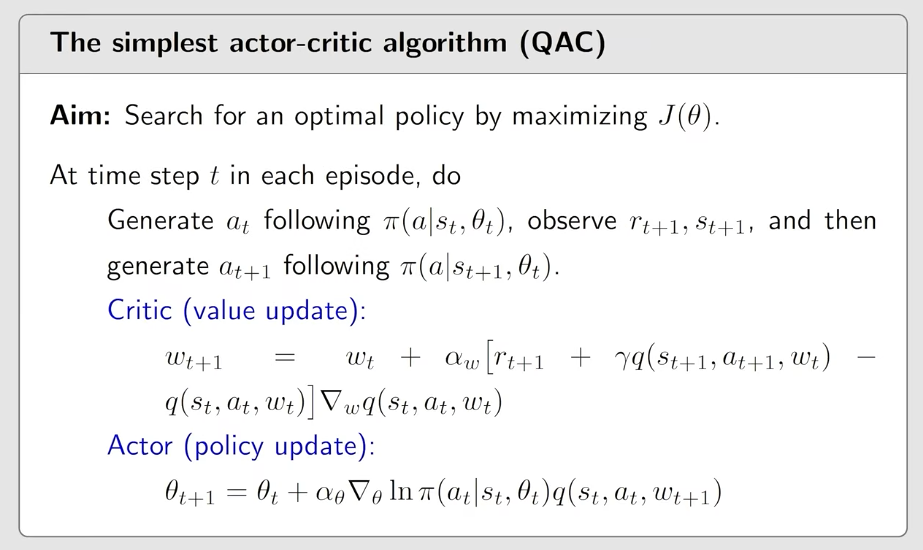

In [1]:
import random
import math
import torch
from torch import nn 
from torch import optim
from collections import deque

from frozen_lake_environment import (generate_grid_randomly,
                                     FrozenLakeEnvironment,
                                     State)
import numpy as np
from matplotlib import pyplot
from visual_utils import (render_policy_and_value, 
                          animate_policy_value_video,
                          plot_trajectory_history)

In [2]:
class PNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.ffn = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
    def forward(self, state):
        return self.ffn(state)


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.ffn = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, state):
        return self.ffn(state)

In [3]:
def random_choice(values, probs):
    r = random.random()
    cumulative = 0.0
    for i in range(len(probs)):
        p = probs[i]
        cumulative += p.item()
        if r <= cumulative:
            return values[i], probs[i]
    return values[-1], probs[-1]  # fallback for floating point edge case


def soft_policy(p_net, state_feat_vec, env):    
    state_feat_vec = torch.FloatTensor(state_feat_vec).unsqueeze(0) # 1 X state_dim
    action_probs = p_net(state_feat_vec).squeeze(0)  # 1 X n_actions
    action, action_prob = random_choice(env.all_action_idx,
                                        action_probs)
    
    return action, action_prob

def get_policy_table(p_net, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    policy = np.zeros(env.n_states, dtype=np.int8)

    for state in states:
        state_feat_vec = state.get_state_feature_vec(env.n_states)
        state_feat_vec = torch.Tensor(state_feat_vec).unsqueeze(0) # 1 X feat_vec
        with torch.no_grad():
            action_probs = p_net(state_feat_vec).squeeze(0)
            policy[state.idx] = torch.argmax(action_probs).item()
    return policy

In [4]:
def get_approx_Qsa(q_net, state, action=None):
    state = torch.FloatTensor(state).unsqueeze(0)
    q_values = q_net(state).squeeze(0)
    if action is None:
        return q_values
    return q_values[action]

def get_Q_table(q_net, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.int8)
    for state in states:
        state_feat_vec = state.get_state_feature_vec(env.n_states)
        state_feat_vec = torch.Tensor(state_feat_vec).unsqueeze(0) # 1 X feat_vec
        with torch.no_grad():
            q_values = q_net(state_feat_vec).unsqueeze(0)    
        Q[state.idx, :] = q_values.detach().numpy()
    return Q

## Training step

In [5]:
def run_episode(env, p_net, p_optimizer, q_net, q_optimizer,
                state, episode_idx, max_step=1000, gamma=0.99):
    step = 0
    trajectory = []
    

    # -------- get initial state ---------------
    state_feature_vec = state.get_state_feature_vec(env.n_states)    
    action, action_prob = soft_policy(p_net,
                                      state_feature_vec,
                                      env)
    for _ in range(max_step):
        trajectory.append(state.coord)
        result = env.step(state, action)
        reward = result["reward"]

        next_state = result["new_state"]
        is_terminated = result["is_terminated"]

        
        next_state_feature_vec = next_state.get_state_feature_vec(env.n_states)    
        next_action, next_action_prob = soft_policy(p_net,
                                                    next_state_feature_vec,
                                                    env)

        # ======= value update ======================
        next_q_sa = get_approx_Qsa(q_net, next_state_feature_vec, next_action)
        q_sa =  get_approx_Qsa(q_net, state_feature_vec, action)
        
        td_error = reward + gamma * next_q_sa * (1 - int(is_terminated)) - q_sa
        value_loss = td_error ** 2  # MSE loss

        q_optimizer.zero_grad()
        value_loss.backward()
        q_optimizer.step()
        
        # ======= policy update =====================
        _, fresh_action_prob = soft_policy(p_net, state_feature_vec, env)
        q_sa =  get_approx_Qsa(q_net, state_feature_vec, action)
        loss = -torch.log(fresh_action_prob) * q_sa.detach()
        
        p_optimizer.zero_grad()
        loss.backward()
        p_optimizer.step()
        
        state = next_state
        action = next_action
        action_prob = next_action_prob
        state_feature_vec = next_state_feature_vec
        
        if is_terminated:
            break

    # print("q loss: ", value_loss.item(), "p loss: ", loss.item())
    trajectory.append(state.coord)
    return p_net, q_net, trajectory

In [15]:
def run_QAC(env, n_episodes=500, gamma=0.99, q_lr=0.001,
            p_lr=0.001):
    
    policy_histories = []
    Q_histories = []
    trajectory_histories = []
  
    p_net = PNetwork(env.n_states,
                     env.n_actions)
    q_net = QNetwork(env.n_states,
                     env.n_actions)
    
    p_optimizer = optim.Adam(p_net.parameters(),
                           lr=p_lr)
    p_scheduler = optim.lr_scheduler.CosineAnnealingLR(p_optimizer,
                                                     T_max=n_episodes,
                                                     eta_min=0.00001)

    q_optimizer = optim.Adam(q_net.parameters(),
                             lr=q_lr)
    q_scheduler = optim.lr_scheduler.CosineAnnealingLR(q_optimizer,
                                                     T_max=n_episodes,
                                                     eta_min=0.00001)
    
    for episode_idx in range(n_episodes):
        # --- initial state action pair -----
        state = env.find('S') 
        # -----------------------------------

        p_net, q_net, trajectory = run_episode(env,
                                                p_net,
                                                p_optimizer,
                                                q_net,
                                                q_optimizer,
                                                state,
                                                episode_idx,
                                                gamma=gamma)
        q_scheduler.step()
        p_scheduler.step()
        
        trajectory_histories.append(trajectory)

        if episode_idx % 500 == 0:
            policy = get_policy_table(p_net, env)
            Q_table = get_Q_table(q_net, env)
            policy_histories.append(policy)
            Q_histories.append(Q_table)

    return policy_histories, Q_histories, trajectory_histories

In [16]:
lake_grid = [["G", "F", "F", "F"],
             ["F", "F", "F", "F"],
             ["F", "F", "H", "F"],
             ["F", "H", "S", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [17]:
torch.autograd.set_detect_anomaly(True)

In [18]:
policy_histories, q_histories, trajectory_histories = run_QAC(frozen_lake, n_episodes=20000)

In [19]:
policy = policy_histories[-1]
q_table = q_histories[-1]

In [20]:
policy

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0], dtype=int8)

In [21]:
q_table

array([[1, 0, 0, 0],
       [2, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [2, 1, 1, 2],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [1, 0, 1, 1],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 1],
       [0, 0, 0, 0],
       [0, 0, 0, 0]], dtype=int8)

# Render policy

In [22]:
import pandas as pd
from IPython.display import display

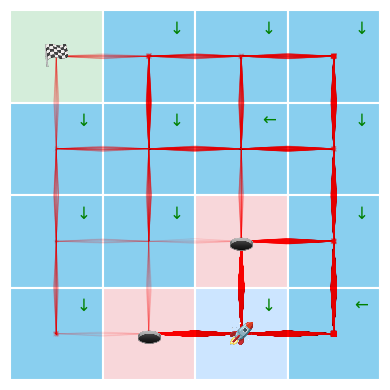

In [23]:
plot_trajectory_history(frozen_lake, trajectory_histories, policy)